# Problem Statement and Objective

Understanding customer behavior is essential for any retail business aiming to improve sales, enhance customer satisfaction, and design targeted marketing campaigns. However, customers often exhibit diverse purchasing patterns, making it difficult to manually identify meaningful groups.

This project focuses on applying unsupervised machine learning to segment mall customers based on their demographic attributes and spending behavior. By clustering customers into distinct groups, the mall can:

Personalize marketing strategies

Improve customer engagement

Allocate resources more effectively

Identify high‑value and at‑risk customer groups.

# Dataset Understanding and Description

The Mall_Customers.csv dataset, which contains 200 customer records with the following features:
CustomerID – Unique identifier (not used for modeling)
Gender – Male/Female
Age – Customer age in years
Annual Income (k$) – Estimated yearly income
Spending Score (1–100) – Score assigned by the mall based on spending behavior and engagement

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [55]:
df = pd.read_csv('Mall_Customers.csv')

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [56]:
df.shape

(200, 5)

In [57]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [59]:
df.isnull().sum() #looking for missing values


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Text(0.5, 1.0, 'Age Distribution')

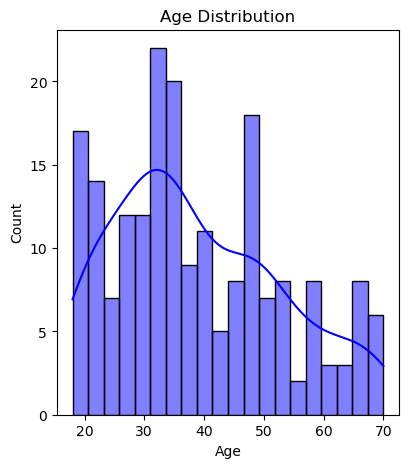

In [60]:

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=20, kde=True, color='blue')
plt.title('Age Distribution')

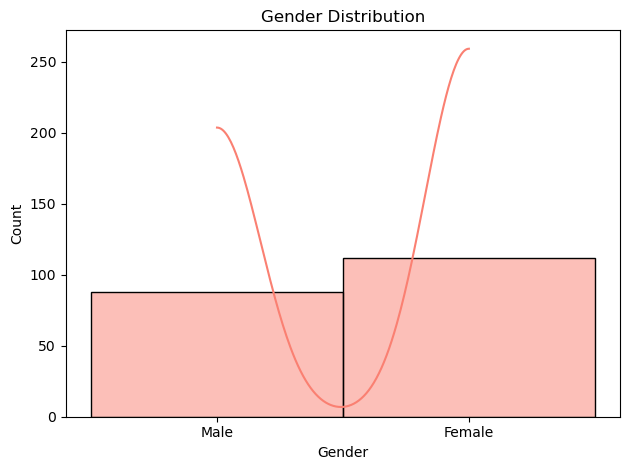

In [61]:
#Gender distribution

sns.histplot(df['Gender'], bins=15, kde=True, color='salmon')
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

In [63]:
#Prepare Data and Apply K-Means Clustering

# We'll cluster based on spending habits: Income + Spending Score
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

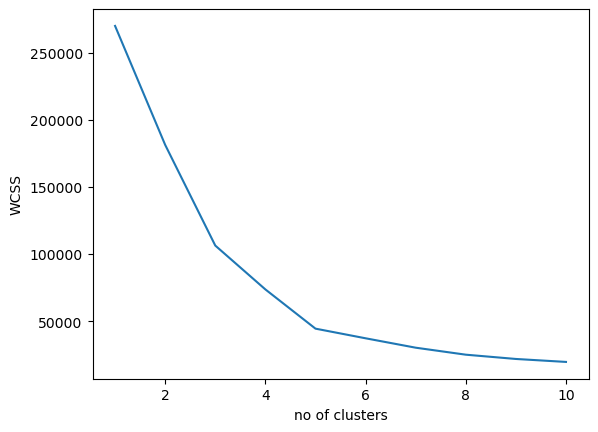

In [64]:
#Elbow Method to find optimal K
# =========================
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 10, max_iter = 300, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.xlabel("no of clusters")
plt.ylabel("WCSS")
plt.show()

C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Cluster counts:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


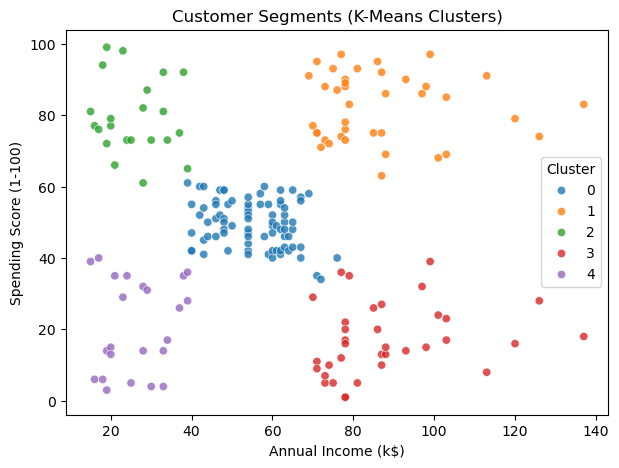

In [65]:
# Choosing K (commonly 4 or 5 for this dataset)
optimal_k = 5

# 6. Apply K-Means Clustering

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# Visualizing clusters in Income vs Spending Score space
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    alpha=0.8
)
plt.title("Customer Segments (K-Means Clusters)")
plt.legend(title="Cluster")
plt.show()

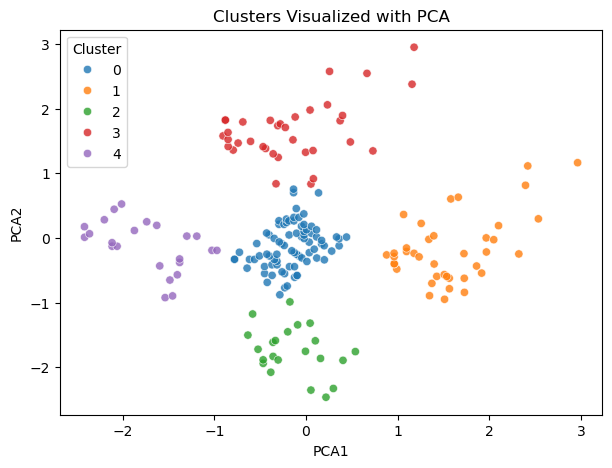

In [68]:
# 7. PCA for visualization 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8
)
plt.title("Clusters Visualized with PCA")
plt.legend(title="Cluster")
plt.show()

# Conclusion

The application of K-Means clustering successfully revealed distinct customer segments within the mall’s customer base. After performing EDA, selecting relevant features, and determining the optimal number of clusters, the analysis produced clear and interpretable groups.